In [1]:
#pip install pandas xarray numba

In [2]:
#conda  install xarray

In [3]:
import os
import time
import xarray as xr
import numpy as np
import scipy.ndimage
from scipy.ndimage import gaussian_filter1d

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm, ListedColormap, LinearSegmentedColormap
from matplotlib import ticker

In [4]:
def create_masked_colormap(cmap, clevels):
    base_cmap = cmap(np.linspace(0, 1, len(clevels) - 1))
    alphas = np.ones(len(clevels) - 1)
    mid = len(alphas) // 2
    alphas[mid - 1: mid + 1] = 0.0  # transparent center
    rgba = np.concatenate([base_cmap[:, :3], alphas[:, None]], axis=1)
    return LinearSegmentedColormap.from_list("masked", rgba, N=len(rgba))

# === Color utilities ===
def hex_to_rgb(value):
    value = value.lstrip('#')
    lv = len(value)
    return tuple(int(value[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))

def rgb_to_dec(rgb_tuple):
    return [val / 255 for val in rgb_tuple]

def get_continuous_cmap(hex_list, float_list=None):
    if float_list is not None:
        if len(float_list) != len(hex_list):
            raise ValueError("float_list must be the same length as hex_list")
        if float_list[0] != 0.0 or float_list[-1] != 1.0:
            raise ValueError("float_list must start with 0.0 and end with 1.0")
    else:
        float_list = np.linspace(0, 1, len(hex_list))

    rgb_list = [rgb_to_dec(hex_to_rgb(hx)) for hx in hex_list]

    cdict = {"red": [], "green": [], "blue": []}
    for i, (r, g, b) in enumerate(rgb_list):
        f = float_list[i]
        cdict["red"].append([f, r, r])
        cdict["green"].append([f, g, g])
        cdict["blue"].append([f, b, b])

    return mcolors.LinearSegmentedColormap('custom_cmap', segmentdata=cdict, N=256)

In [5]:
def plot_zonal_metrics_comparison(
        base_dir, 
        fig_dir,
        model_dict, 
        var_dict,
        fig_name=None,
        sig_level=0.1, 
        cmap=None
    ):
    
    start_time = time.time()

    if cmap is None:
        cmap = get_white_centered_colormap()

    nrow, ncol = len(var_dict), len(model_dict)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol + 2.5, 3.5 * nrow), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    fontz = 20

    datasets = {}
    for var_key in var_dict:
        datasets[var_key] = {}
        for model_key in model_dict:
            fpath = os.path.join(base_dir, f"{var_key}_zonal_clim_ttest_{model_key}.nc")
            datasets[var_key][model_key] = xr.open_dataset(fpath) if os.path.exists(fpath) else None

    for i, var_key in enumerate(var_dict):
        clevels = np.array(var_dict[var_key]['level'])
        masked_cmap = create_masked_colormap(cmap, clevels)
        norm = TwoSlopeNorm(vmin=clevels[0], vcenter=0, vmax=clevels[-1])
        plots = []

        for j, model_key in enumerate(model_dict):
            ax = axes[i, j]
            ds = datasets[var_key][model_key]

            if ds is None:
                ax.set_title(f"{model_key}\n[Missing data]", fontsize=fontz * 1.1)
                ax.axis("off")
                continue

            diff = ds["diff"].sel(season="ANN")
            pval = ds["p_value"].sel(season="ANN")
            lat = diff.lat
            lev = diff.lev / 100.0  # hPa

            # --- Load PHIS for topography mask ---
            phis_path = os.path.join(base_dir, f"PHIS_zonalmean_{model_key}.nc")
            if os.path.exists(phis_path):
                phis_ds = xr.open_dataset(phis_path)
                phis_raw = phis_ds["PHIS"] / 9.80665  # convert m²/s² to meters
                phis = xr.DataArray(
                    gaussian_filter1d(phis_raw, sigma=2),
                    coords={"lat": phis_raw.lat}, dims="lat"
                )
                mask = np.zeros(diff.shape, dtype=bool)
                for k, p in enumerate(diff.lev):
                    h = 44330 * (1 - (p / 101325.0) ** (1 / 5.255))
                    mask[k, :] = phis > h
                diff = diff.where(~mask)
                pval = pval.where(~mask)

            cf = ax.contourf(lat, lev, diff.transpose("lev", "lat"),
                             levels=clevels, cmap=masked_cmap, norm=norm, extend="both")
            plots.append(cf)

            threshold = np.min(np.diff(clevels)) * 1.5
            contour_levels = [lvl for lvl in clevels if abs(lvl) > threshold]
            if contour_levels:
                ax.contour(lat, lev, diff.transpose("lev", "lat"),
                           levels=contour_levels, colors='k', linewidths=0.5, alpha=0.2)

            sig_mask = xr.where(pval < sig_level, 1, np.nan)
            sig_mask_interp = scipy.ndimage.zoom(sig_mask, zoom=2, order=1)
            lat_fine = np.linspace(lat.min(), lat.max(), sig_mask_interp.shape[1])
            lev_fine = np.linspace(lev.min(), lev.max(), sig_mask_interp.shape[0])
            ax.contourf(lat_fine, lev_fine, sig_mask_interp,
                        levels=[0, 2], colors='none', hatches=['..', None])

            ax.invert_yaxis()
            ax.set_yticks([1000, 800, 600, 400, 200, 10])
            ax.set_ylim(1000, 0)
            ax.tick_params(labelsize=fontz)

            if j == 0:
                ax.set_ylabel("Pressure (hPa)", fontsize=fontz)
            if i == nrow - 1:
                ax.set_xlabel("Latitude", fontsize=fontz)

            ax.set_title(f"({chr(97 + i)}{j + 1}) {model_dict[model_key]}", loc="left", fontsize=fontz)
            ax.set_title(var_dict[var_key]['alias'], loc="right", fontsize=fontz)

        cbar_ax = fig.add_axes([0.93, (nrow - i * 1.04 - 0.52) * 0.22, 0.012, 0.7 / nrow])
        cbar = fig.colorbar(plots[-1], cax=cbar_ax, ticks=clevels)
        for idx, tick_label in enumerate(cbar.ax.get_yticklabels()):
            if idx % 2 != 0:
                tick_label.set_visible(False)
            else:
                tick_label.set_fontsize(fontz)
        cbar.set_label(f"{var_dict[var_key]['alias']} ({var_dict[var_key]['unit']})", fontsize=fontz)
        cbar.ax.tick_params(labelsize=fontz * 0.95)
        cbar.ax.yaxis.set_tick_params(size=5)
        cbar.ax.yaxis.grid(True, linestyle='-', color="black", alpha=0.3)

    plt.subplots_adjust(left=0.06, right=0.91, top=0.94, bottom=0.08, hspace=0.28, wspace=0.15)
    os.makedirs(fig_dir, exist_ok=True)
    if fig_name is not None:
        fig_path_out = os.path.join(fig_dir, fig_name)
    else:
        fig_path_out = os.path.join(fig_dir, "zonal_mean_bias_nudge_vs_clim.pdf")
    plt.savefig(fig_path_out, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"[INFO] Plotting completed in {time.time() - start_time:.2f} seconds. Saved to {fig_path_out}")


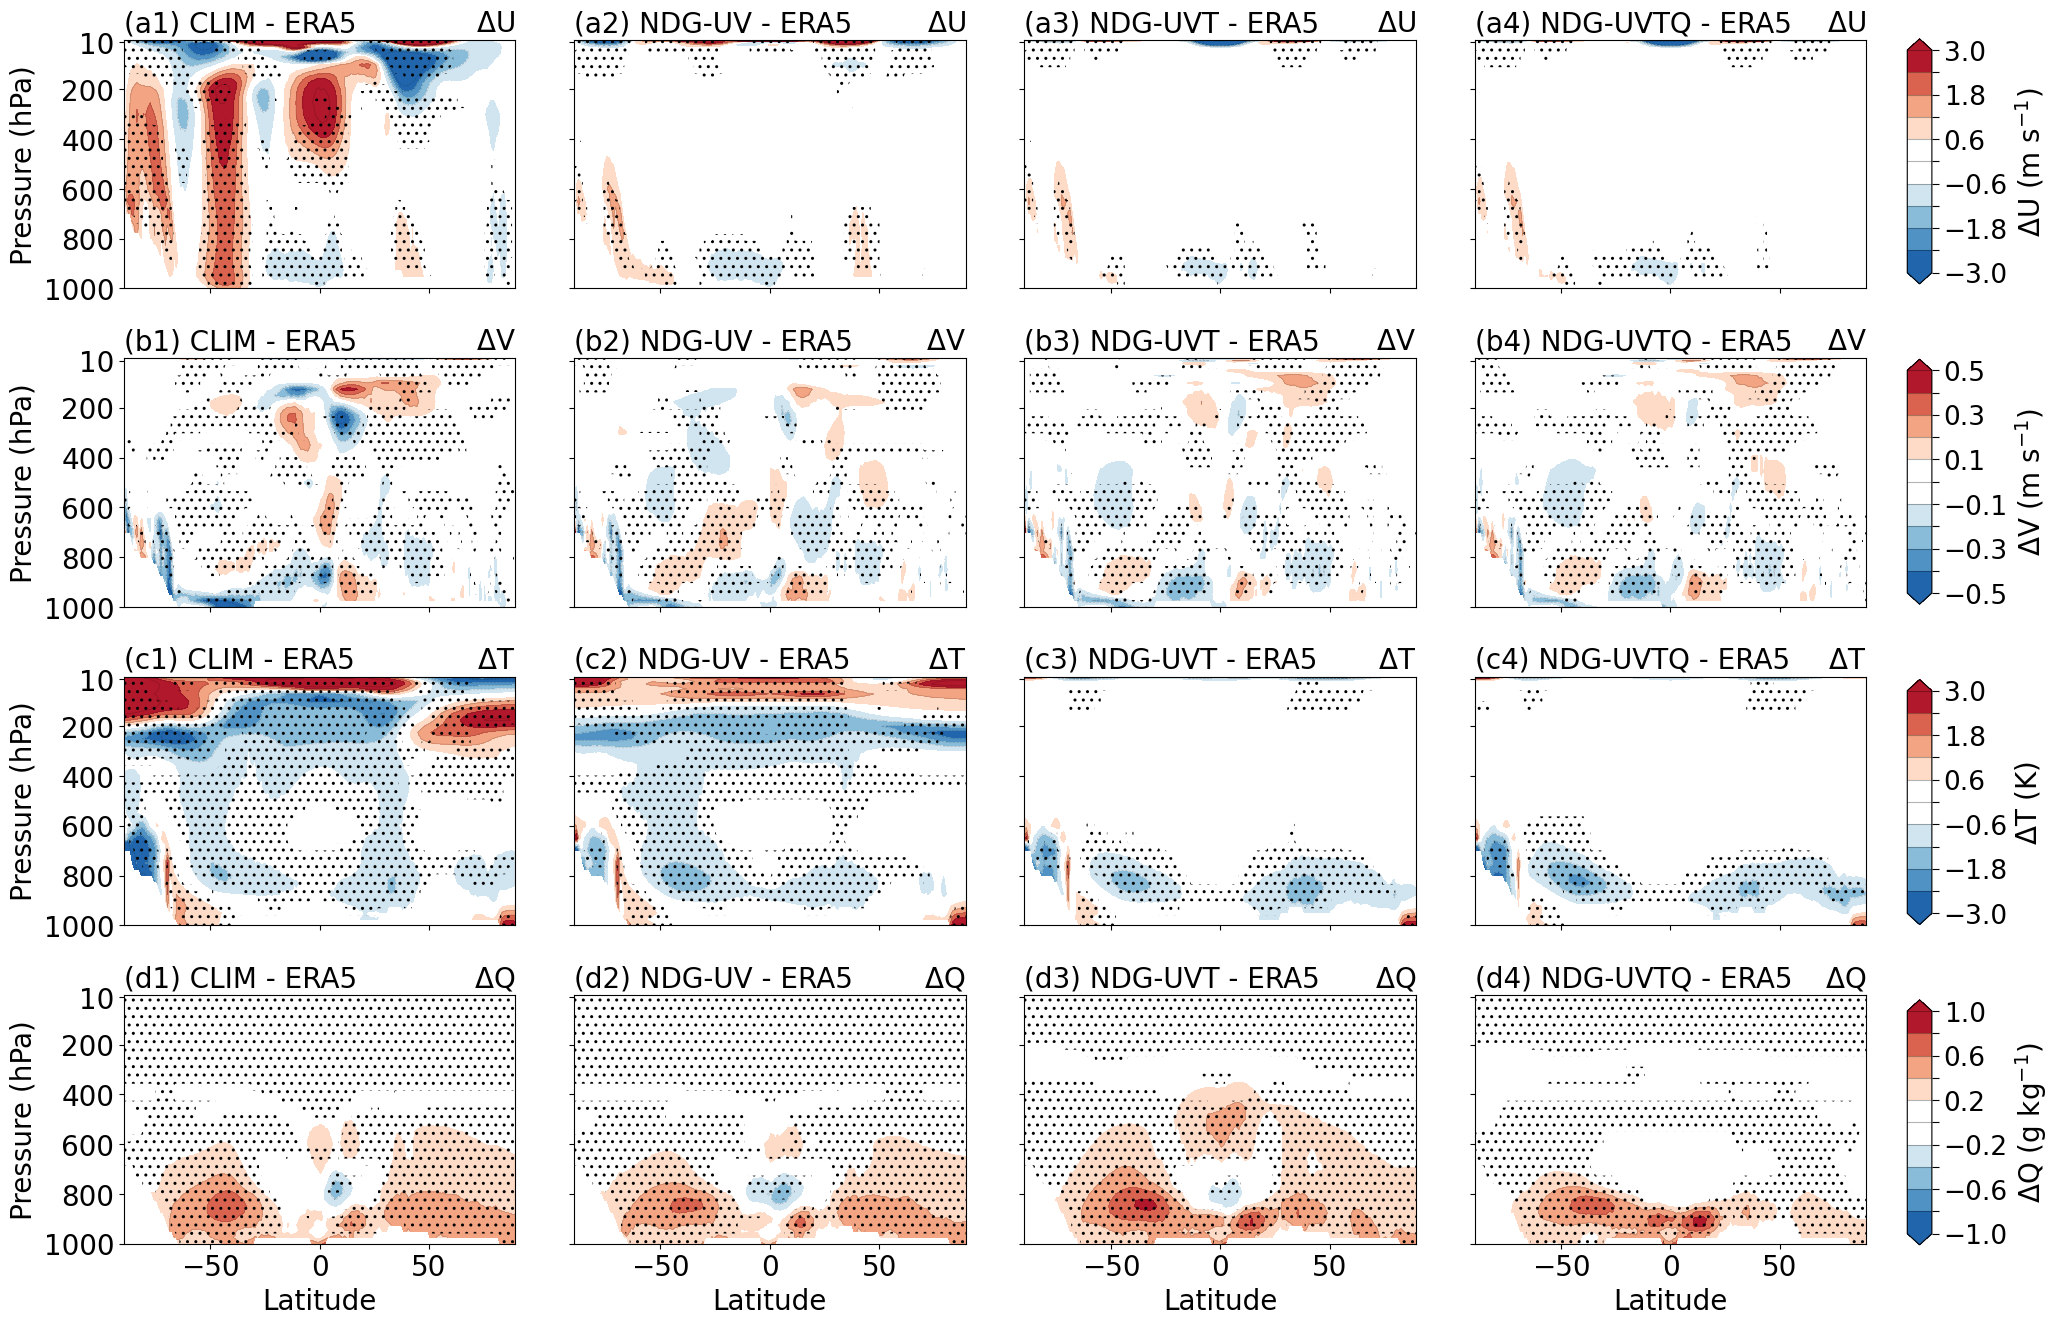

[INFO] Plotting completed in 5.52 seconds. Saved to ./Figure_03.pdf


In [7]:
if __name__ == "__main__":
    top_path  = "/home/x-szhang3/nudging_analysis"
    out_path  = f"{top_path}/nudging_evaluation/data/zonal_mean"
    fig_path  = "./"
    frequency = "monthly"
    fig_name = "Figure_03.pdf"

    var_dict = {
        'U': { 'alias': '$\Delta$U', 'unit': 'm s$^{-1}$', "level": np.linspace(-3, 3, 11)},
        'V': { 'alias': '$\Delta$V', 'unit': 'm s$^{-1}$', "level": np.linspace(-0.5, 0.5, 11)},
        'T': { 'alias': '$\Delta$T', 'unit': 'K',             "level": np.linspace(-3, 3, 11)},
        'Q': { 'alias': '$\Delta$Q', 'unit': 'g kg$^{-1}$', "level": np.linspace(-1.0, 1.0, 11)}
    }

    model_dict = {
        'CLIM':    'CLIM - ERA5',
        'NDGUV':   'NDG-UV - ERA5',
        'NDGUVT':  'NDG-UVT - ERA5',
        'NDGUVTQ': 'NDG-UVTQ - ERA5',
        #'NDGUVTQ_SRF1': 'NDG-UVTQ+SRF - ERA5',
    }

    # Blue → White → Red diverging colormap
    hex_colors = ["#2166ac", "#67a9cf", "#d1e5f0", "#f7f7f7", "#fddbc7", "#ef8a62", "#b2182b"]
    cmap = get_continuous_cmap(hex_colors)
    
    plot_zonal_metrics_comparison(
        base_dir=os.path.join(out_path, frequency),
        fig_dir=fig_path,
        model_dict=model_dict,
        var_dict=var_dict,
        fig_name=fig_name,
        sig_level=0.05,
        cmap=cmap
    )